In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

path = r'C:\Users\Anirudh\Desktop\olist_project\\'
os.chdir(path)

# Load the master file you saved yesterday
master = pd.read_csv('olist_master.csv')

print("Master loaded ✅")
print("Shape:", master.shape)

Master loaded ✅
Shape: (110173, 38)


In [4]:
#Count on time vs late
sla_counts = master['is_late'].value_counts()
sla_labels = ['On Time', 'Late']
sla_values = [sla_counts[0], sla_counts[1]]

print("On Time orders :", sla_values[0])
print("Late orders    :", sla_values[1])

On Time orders : 102028
Late orders    : 8145


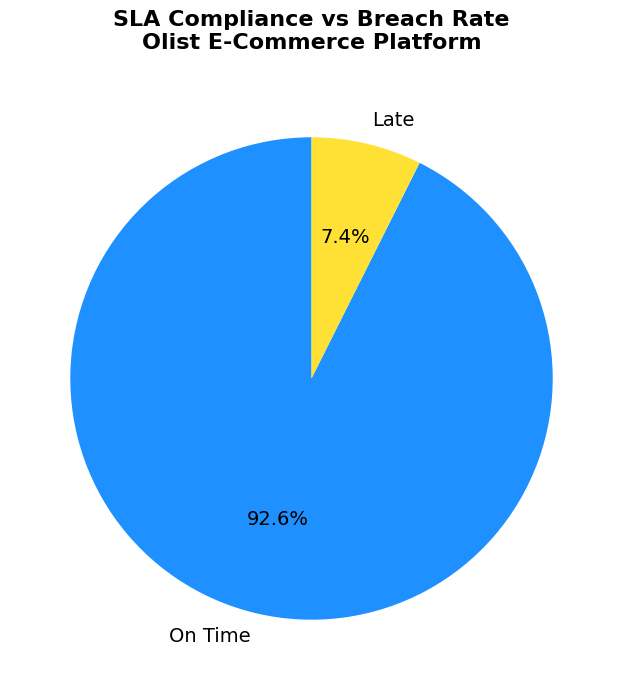

Chart 1 saved ✅


In [10]:
colors = ['#1E90FF', '#FFE135']

plt.figure(figsize=(7, 7))
plt.pie(sla_values, labels=sla_labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 14})
plt.title('SLA Compliance vs Breach Rate\nOlist E-Commerce Platform',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart1_sla_overview.png', dpi=150)
plt.show()
print("Chart 1 saved ✅")

In [11]:
print("=== DELAY DAYS STATISTICS ===")
print(master['delay_days'].describe())
print("\nOrders delivered early (negative delay):",
      (master['delay_days'] < 0).sum())
print("Orders delivered on exact date         :",
      (master['delay_days'] == 0).sum())
print("Orders delivered late (positive delay) :",
      (master['delay_days'] > 0).sum())

=== DELAY DAYS STATISTICS ===
count    110173.000000
mean        -11.431058
std          10.167992
min        -146.000000
25%         -17.000000
50%         -12.000000
75%          -7.000000
max         189.000000
Name: delay_days, dtype: float64

Orders delivered early (negative delay): 100510
Orders delivered on exact date         : 1518
Orders delivered late (positive delay) : 8145


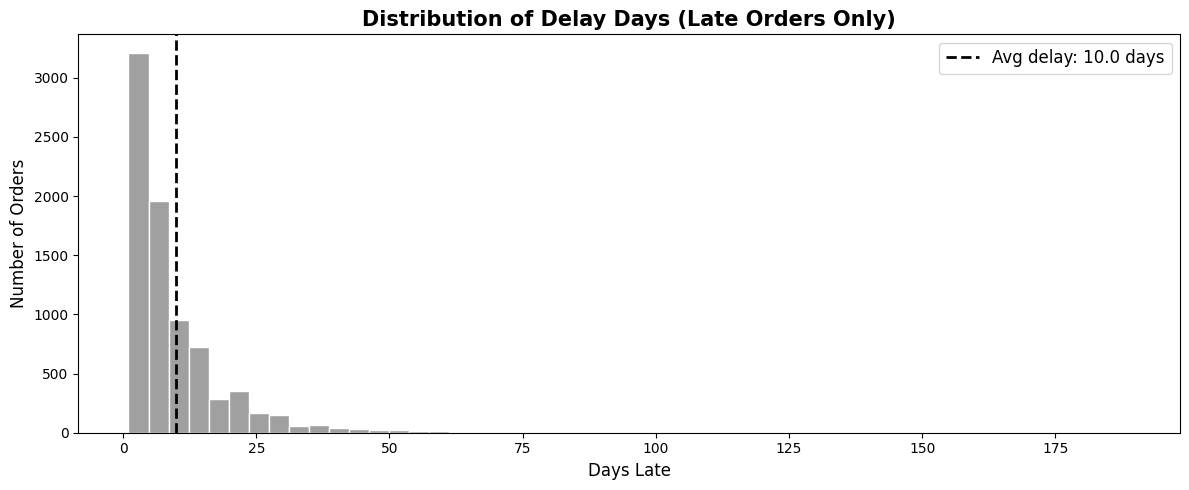

Chart 2 saved ✅


In [13]:
late_orders = master[master['is_late'] == 1]

plt.figure(figsize=(12, 5))
sns.histplot(late_orders['delay_days'], bins=50,
             color='#808080', edgecolor='white')
plt.axvline(late_orders['delay_days'].mean(), color='black',
            linestyle='--', linewidth=2,
            label=f"Avg delay: {late_orders['delay_days'].mean():.1f} days")
plt.title('Distribution of Delay Days (Late Orders Only)',
          fontsize=15, fontweight='bold')
plt.xlabel('Days Late', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('chart2_delay_distribution.png', dpi=150)
plt.show()
print("Chart 2 saved ✅")

In [14]:
def delay_bucket(days):
    if days <= 0:
        return 'On Time'
    elif days <= 3:
        return '1-3 Days Late'
    elif days <= 7:
        return '4-7 Days Late'
    elif days <= 14:
        return '8-14 Days Late'
    else:
        return '15+ Days Late'

master['delay_bucket'] = master['delay_days'].apply(delay_bucket)

bucket_counts = master['delay_bucket'].value_counts().reindex([
    'On Time', '1-3 Days Late', '4-7 Days Late',
    '8-14 Days Late', '15+ Days Late'
])

print(bucket_counts)

delay_bucket
On Time           102028
1-3 Days Late       2665
4-7 Days Late       1991
8-14 Days Late      1847
15+ Days Late       1642
Name: count, dtype: int64


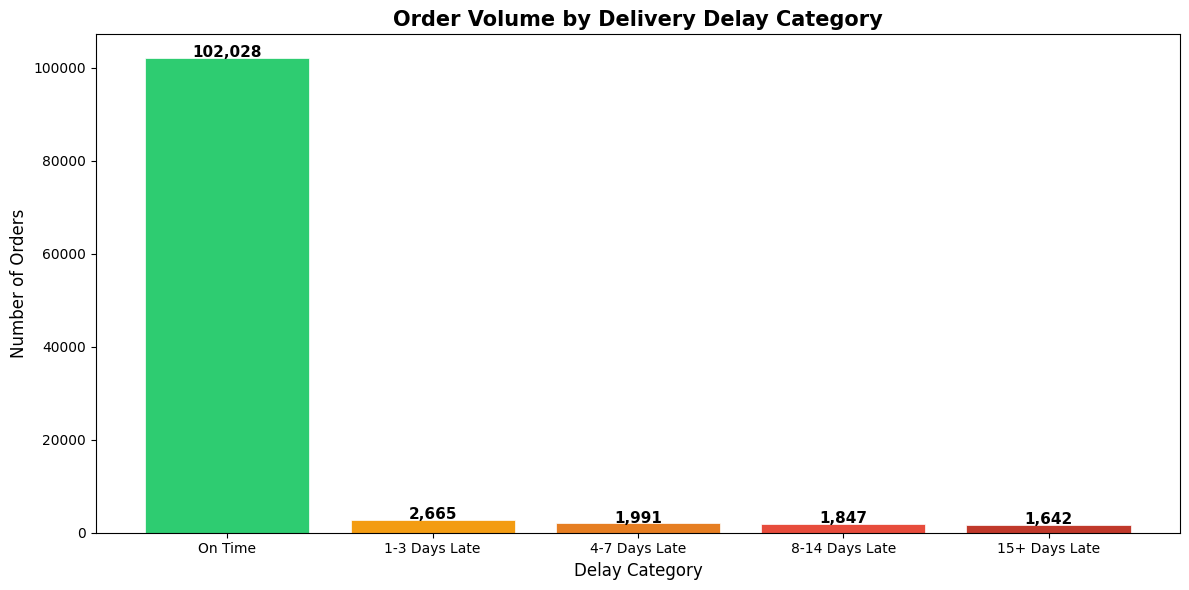

Chart 3 saved ✅


In [15]:
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']

plt.figure(figsize=(12, 6))
bars = plt.bar(bucket_counts.index, bucket_counts.values,
               color=colors, edgecolor='white', linewidth=0.5)

# Add value labels on top of bars
for bar, val in zip(bars, bucket_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'{val:,}', ha='center', fontsize=11, fontweight='bold')

plt.title('Order Volume by Delivery Delay Category',
          fontsize=15, fontweight='bold')
plt.xlabel('Delay Category', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.tight_layout()
plt.savefig('chart3_delay_buckets.png', dpi=150)
plt.show()
print("Chart 3 saved ✅")

In [16]:
state_analysis = master.groupby('customer_state').agg(
    total_orders    = ('is_late', 'count'),
    late_orders     = ('is_late', 'sum'),
    avg_delay_days  = ('delay_days', 'mean')
).reset_index()

state_analysis['breach_rate'] = round(
    (state_analysis['late_orders'] / state_analysis['total_orders']) * 100, 2
)

# Sort by breach rate
state_analysis = state_analysis.sort_values('breach_rate', ascending=False)

print(state_analysis.head(10))

   customer_state  total_orders  late_orders  avg_delay_days  breach_rate
1              AL           427           99       -8.189696        23.19
9              MA           799          157       -9.270338        19.65
24             SE           375           61       -9.442667        16.27
5              CE          1425          211      -10.480000        14.81
16             PI           523           77      -10.913958        14.72
4              BA          3683          475      -10.400489        12.90
18             RJ         14140         1756      -11.393706        12.42
13             PA          1054          128      -13.650854        12.14
26             TO           310           37      -11.732258        11.94
7              ES          2225          262      -10.040899        11.78


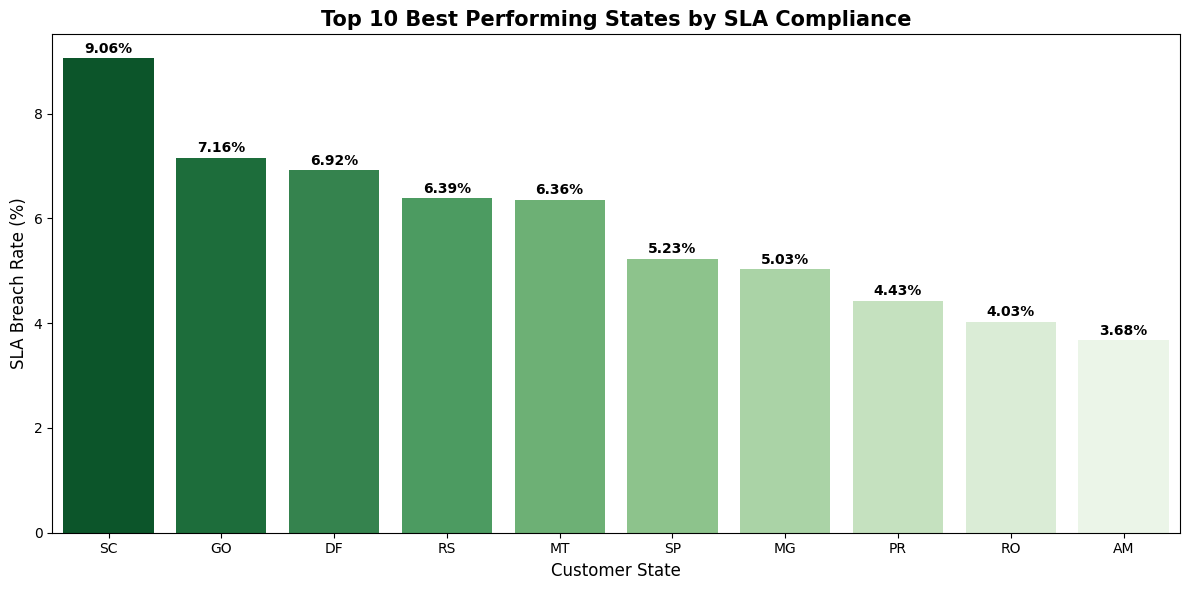

Chart 5 saved ✅


In [17]:
bottom10_states = state_analysis[state_analysis['total_orders'] > 100].tail(10)

plt.figure(figsize=(12, 6))
bars = sns.barplot(data=bottom10_states, x='customer_state',
                   y='breach_rate', palette='Greens_r')

for bar, val in zip(bars.patches, bottom10_states['breach_rate']):
    bars.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.1,
              f'{val}%', ha='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Best Performing States by SLA Compliance',
          fontsize=15, fontweight='bold')
plt.xlabel('Customer State', fontsize=12)
plt.ylabel('SLA Breach Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('chart5_best_states.png', dpi=150)
plt.show()
print("Chart 5 saved ✅")

In [19]:
master['order_purchase_timestamp'] = pd.to_datetime(
    master['order_purchase_timestamp'])
master['year_month'] = master['order_purchase_timestamp'].dt.to_period('M')

monthly = master.groupby('year_month').agg(
    total_orders = ('is_late', 'count'),
    late_orders  = ('is_late', 'sum')
).reset_index()

monthly['breach_rate'] = round(
    (monthly['late_orders'] / monthly['total_orders']) * 100, 2)

print(monthly.tail(10))

   year_month  total_orders  late_orders  breach_rate
13    2017-11          8474         1097        12.95
14    2017-12          6187          486         7.86
15    2018-01          8037          501         6.23
16    2018-02          7518         1140        15.16
17    2018-03          8017         1575        19.65
18    2018-04          7827          354         4.52
19    2018-05          7810          572         7.32
20    2018-06          7007           90         1.28
21    2018-07          6960          276         3.97
22    2018-08          7142          622         8.71


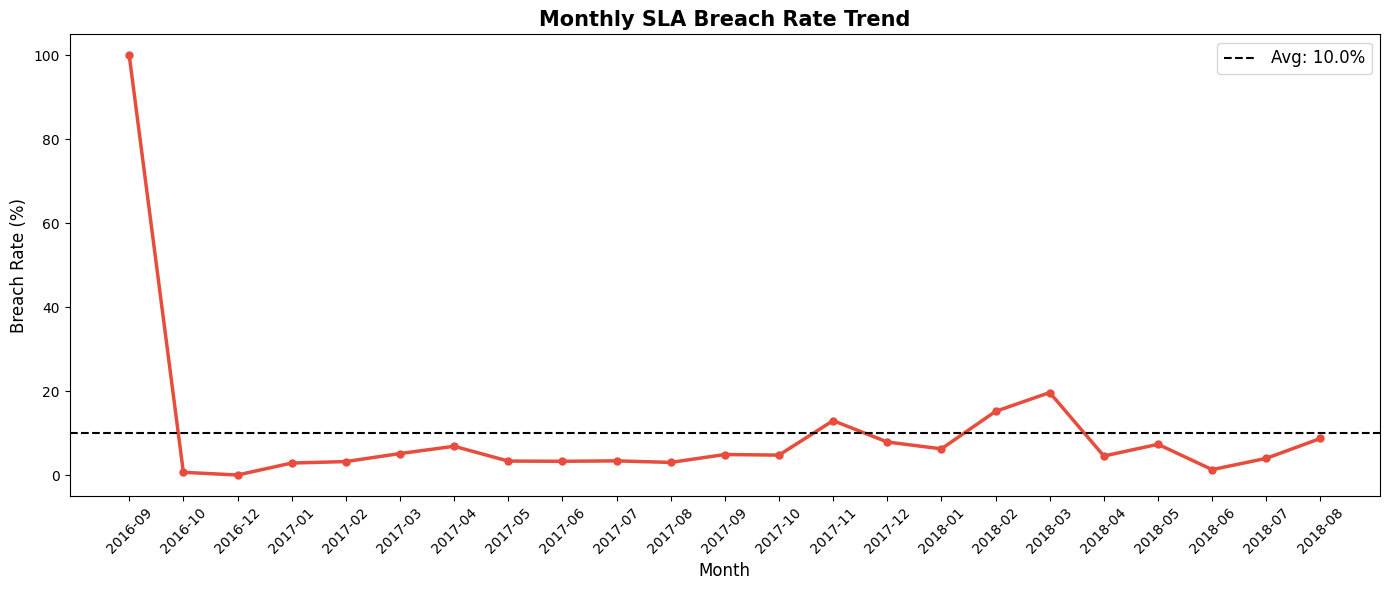

Chart 6 saved ✅


In [20]:
plt.figure(figsize=(14, 6))
plt.plot(monthly['year_month'].astype(str),
         monthly['breach_rate'],
         color='#e74c3c', linewidth=2.5, marker='o', markersize=5)
plt.axhline(monthly['breach_rate'].mean(), color='black',
            linestyle='--', linewidth=1.5,
            label=f"Avg: {monthly['breach_rate'].mean():.1f}%")
plt.title('Monthly SLA Breach Rate Trend',
          fontsize=15, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Breach Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('chart6_monthly_trend.png', dpi=150)
plt.show()
print("Chart 6 saved ✅")

In [ ]:
# ===================== DAY 3 OBSERVATIONS =====================
# 1. Average delay for late orders (days)      = 10 days
# 2. Most common delay bucket                  = On time
# 3. Worst performing state (breach rate)      = AM
# 4. Best performing state (breach rate)       = SC
# 5. Which month had highest breach rate       = Nov 2016
# 6. One business insight from today           = 
# ==============================================================